<a href="https://colab.research.google.com/github/Aravind11-05/Customer-Shopping-Behaviour/blob/main/air_qualityfrom_google_colab_import_files_uploaded_%3D_files_upload().ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving city_day.csv.zip to city_day.csv.zip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/city_day.csv.zip")
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
df = df[['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'AQI']]
df.dropna(inplace=True)

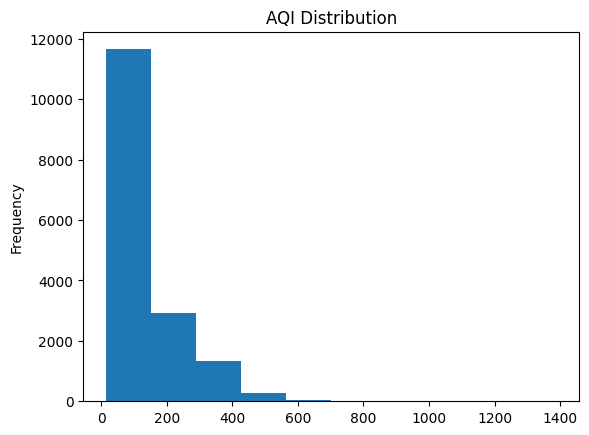

In [ ]:
df['AQI'].plot(kind='hist')
plt.title("AQI Distribution")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['PM2.5', 'PM10', 'NO2', 'CO', 'SO2']]
y = df['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
print("Accuracy:", r2_score(y_test, y_pred))

Accuracy: 0.9064273360971037


In [ ]:
model.predict([[50, 80, 30, 1, 10]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([103.54])

In [ ]:
aqi = model.predict([[50, 80, 30, 1, 10]])

if aqi > 200:
    print("⚠️ Alert: Air Quality is Dangerous!")
else:
    print("Air Quality is Safe")

Air Quality is Safe


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


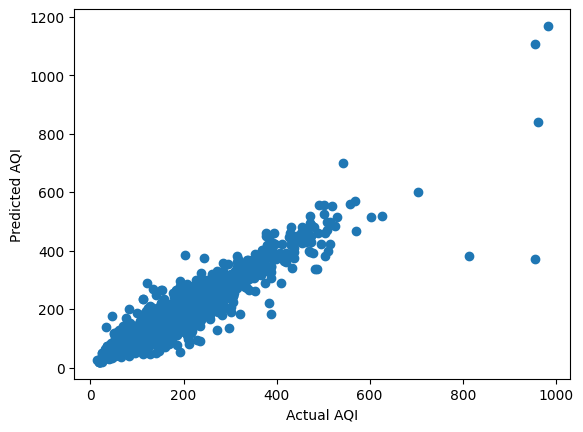

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.show()